In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
)

print("Imports loaded")

Imports loaded


In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "processed_ds"
MODEL_DIR = PROJECT_ROOT / "results" / "models"

OUTPUT_DIR = PROJECT_ROOT / "results" / "missing_modality"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SUBJECTS = [2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]

MODALITY_NAMES = [
    "ECG",
    "EDA",
    "Respiration",
    "Temperature"
]

print("Project Root :", PROJECT_ROOT)
print("Data Folder  :", DATA_DIR)
print("Model Folder :", MODEL_DIR)

Project Root : C:\Users\sanka\OneDrive\Desktop\mulitmodal stress detection
Data Folder  : C:\Users\sanka\OneDrive\Desktop\mulitmodal stress detection\data\processed_ds
Model Folder : C:\Users\sanka\OneDrive\Desktop\mulitmodal stress detection\results\models


In [3]:
# ==========================
# Import Model
# ==========================

sys.path.append(str(PROJECT_ROOT))

from models.cnn_lstm_encoder import MultiModalCNNLSTM

print("Model imported successfully!")
print(MultiModalCNNLSTM)

Model imported successfully!
<class 'models.cnn_lstm_encoder.MultiModalCNNLSTM'>


In [4]:
model = MultiModalCNNLSTM()

print(model)

MultiModalCNNLSTM(
  (encoders): ModuleList(
    (0-3): 4 x ModalityEncoderSeq(
      (conv1): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (seq_pool): AdaptiveAvgPool1d(output_size=100)
  (lstms): ModuleList(
    (0-3): 4 x LSTM(64, 64, batch_first=True)
  )
  (embed_proj): ModuleList(
    (0-3): 4 x Linear(in_features=64, out_features=256, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [5]:
# ==========================
# Data Loader
# ==========================

def load_subject(subject_id):
    """
    Load one subject's processed data.

    Returns:
        X : (N, 4, 3000)
        y : (N,)
    """

    X = np.load(
        DATA_DIR / f"S{subject_id}_X.npy"
    ).astype(np.float32)

    y = np.load(
        DATA_DIR / f"S{subject_id}_y.npy"
    ).astype(np.int64)

    return X, y


print("Data loader created.")

Data loader created.


In [6]:
X, y = load_subject(2)

print("X shape :", X.shape)
print("y shape :", y.shape)
print("X dtype :", X.dtype)
print("y dtype :", y.dtype)

X shape : (140, 4, 3000)
y shape : (140,)
X dtype : float32
y dtype : int64


In [7]:
# ==========================
# Checkpoint Loader
# ==========================

def load_checkpoint(subject_id):

    checkpoint_path = MODEL_DIR / f"cnnlstm_S{subject_id}.pt"

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found:\n{checkpoint_path}"
        )

    model = MultiModalCNNLSTM()

    state_dict = torch.load(
        checkpoint_path,
        map_location="cpu"
    )

    model.load_state_dict(state_dict)

    model.eval()

    return model


print("Checkpoint loader created.")

Checkpoint loader created.


In [8]:
model = load_checkpoint(2)

print("Checkpoint loaded successfully!")

Checkpoint loaded successfully!


In [9]:
print(type(model))

<class 'models.cnn_lstm_encoder.MultiModalCNNLSTM'>


In [10]:
# ==========================
# Evaluation Function
# ==========================

def evaluate_model(
    model,
    X,
    y,
    missing_mask=None,
    batch_size=64,
):

    model.eval()

    all_preds = []
    all_probs = []

    with torch.no_grad():

        for start in range(0, len(X), batch_size):

            end = start + batch_size

            X_batch = torch.tensor(
                X[start:end],
                dtype=torch.float32
            )

            logits = model(
                X_batch,
                missing_mask=missing_mask
            )

            probs = torch.softmax(
                logits,
                dim=1
            )[:, 1].cpu().numpy()

            preds = logits.argmax(
                dim=1
            ).cpu().numpy()

            all_preds.extend(preds)
            all_probs.extend(probs)

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    return {
        "accuracy": accuracy_score(y, all_preds),
        "f1": f1_score(
            y,
            all_preds,
            average="macro"
        ),
        "auroc": roc_auc_score(
            y,
            all_probs
        ),
        "predictions": all_preds,
        "probabilities": all_probs,
    }


print("Evaluation function ready.")

Evaluation function ready.


In [11]:
X, y = load_subject(2)

model = load_checkpoint(2)

full_result = evaluate_model(
    model,
    X,
    y
)

print("Accuracy :", full_result["accuracy"])
print("F1 Score :", full_result["f1"])
print("AUROC    :", full_result["auroc"])

Accuracy : 0.7571428571428571
F1 Score : 0.7277510867078472
AUROC    : 0.8026607538802661


In [12]:
# ==========================
# Missing ECG
# ==========================

mask_no_ecg = [
    True,   # ECG missing
    False,  # EDA
    False,  # Respiration
    False   # Temperature
]

no_ecg_result = evaluate_model(
    model,
    X,
    y,
    missing_mask=mask_no_ecg
)

print("Accuracy :", no_ecg_result["accuracy"])
print("F1 Score :", no_ecg_result["f1"])
print("AUROC    :", no_ecg_result["auroc"])

Accuracy : 0.7642857142857142
F1 Score : 0.7521326251408338
AUROC    : 0.7984725301798472


In [13]:
# ==========================
# Robustness Score
# ==========================

RS = no_ecg_result["f1"] / full_result["f1"]

print(f"Full Modality F1 : {full_result['f1']:.4f}")
print(f"No ECG F1        : {no_ecg_result['f1']:.4f}")
print(f"Robustness Score : {RS:.4f}")

Full Modality F1 : 0.7278
No ECG F1        : 0.7521
Robustness Score : 1.0335


In [14]:
comparison = pd.DataFrame({
    "Scenario": ["Full", "No ECG"],
    "Accuracy": [
        full_result["accuracy"],
        no_ecg_result["accuracy"]
    ],
    "F1": [
        full_result["f1"],
        no_ecg_result["f1"]
    ],
    "AUROC": [
        full_result["auroc"],
        no_ecg_result["auroc"]
    ]
})

comparison

,Scenario,Accuracy,F1,AUROC
0,Full,0.757143,0.727751,0.802661
1,No ECG,0.764286,0.752133,0.798473


In [15]:
# ==========================
# Single Modality Dropout
# ==========================

SINGLE_DROPOUTS = {
    "Full": None,
    "No ECG": [True, False, False, False],
    "No EDA": [False, True, False, False],
    "No Respiration": [False, False, True, False],
    "No Temperature": [False, False, False, True],
}

print(SINGLE_DROPOUTS)

{'Full': None, 'No ECG': [True, False, False, False], 'No EDA': [False, True, False, False], 'No Respiration': [False, False, True, False], 'No Temperature': [False, False, False, True]}


In [16]:
results = []

for scenario, mask in SINGLE_DROPOUTS.items():

    result = evaluate_model(
        model,
        X,
        y,
        missing_mask=mask
    )

    rs = (
        1.0
        if scenario == "Full"
        else result["f1"] / full_result["f1"]
    )

    results.append({
        "Scenario": scenario,
        "Accuracy": result["accuracy"],
        "F1": result["f1"],
        "AUROC": result["auroc"],
        "RS": rs,
    })

results_df = pd.DataFrame(results)

results_df

,Scenario,Accuracy,F1,AUROC,RS
0,Full,0.757143,0.727751,0.802661,1.000000
1,No ECG,0.764286,0.752133,0.798473,1.033503
2,No EDA,0.685714,0.625850,0.752156,0.859979
3,No Respiration,0.642857,0.595282,0.757822,0.817975
4,No Temperature,0.721429,0.591287,0.829022,0.812485


In [17]:
importance = (
    results_df
    .sort_values("RS")
    .reset_index(drop=True)
)

importance

,Scenario,Accuracy,F1,AUROC,RS
0,No Temperature,0.721429,0.591287,0.829022,0.812485
1,No Respiration,0.642857,0.595282,0.757822,0.817975
2,No EDA,0.685714,0.625850,0.752156,0.859979
3,Full,0.757143,0.727751,0.802661,1.000000
4,No ECG,0.764286,0.752133,0.798473,1.033503


In [18]:
results_df.to_csv(
    OUTPUT_DIR / "S2_single_dropout.csv",
    index=False
)

print(f"Saved to: {OUTPUT_DIR / 'S2_single_dropout.csv'}")

Saved to: C:\Users\sanka\OneDrive\Desktop\mulitmodal stress detection\results\missing_modality\S2_single_dropout.csv


In [19]:
def evaluate_subject(subject_id):

    X, y = load_subject(subject_id)

    model = load_checkpoint(subject_id)

    full_result = evaluate_model(
        model,
        X,
        y
    )

    rows = []

    for scenario, mask in SINGLE_DROPOUTS.items():

        result = evaluate_model(
            model,
            X,
            y,
            missing_mask=mask
        )

        rs = (
            1.0
            if scenario == "Full"
            else result["f1"] / full_result["f1"]
        )

        rows.append({

            "Subject": subject_id,

            "Scenario": scenario,

            "Accuracy": result["accuracy"],

            "F1": result["f1"],

            "AUROC": result["auroc"],

            "RS": rs

        })

    return pd.DataFrame(rows)

In [20]:
test_df = evaluate_subject(2)

test_df

,Subject,Scenario,Accuracy,F1,AUROC,RS
0,2,Full,0.757143,0.727751,0.802661,1.000000
1,2,No ECG,0.764286,0.752133,0.798473,1.033503
2,2,No EDA,0.685714,0.625850,0.752156,0.859979
3,2,No Respiration,0.642857,0.595282,0.757822,0.817975
4,2,No Temperature,0.721429,0.591287,0.829022,0.812485


In [21]:
all_results = []

for subject in SUBJECTS:

    print(f"Running Subject {subject}")

    df = evaluate_subject(subject)

    all_results.append(df)

print("Finished!")

Running Subject 2
Running Subject 3
Running Subject 4
Running Subject 5
Running Subject 6
Running Subject 7
Running Subject 8
Running Subject 9
Running Subject 10
Running Subject 11
Running Subject 13
Running Subject 14
Running Subject 15
Running Subject 16
Running Subject 17
Finished!


In [23]:
all_results_df = pd.concat(
    all_results,
    ignore_index=True
)

print(all_results_df.shape)

all_results_df.head()

(75, 6)


,Subject,Scenario,Accuracy,F1,AUROC,RS
0,2,Full,0.757143,0.727751,0.802661,1.000000
1,2,No ECG,0.764286,0.752133,0.798473,1.033503
2,2,No EDA,0.685714,0.625850,0.752156,0.859979
3,2,No Respiration,0.642857,0.595282,0.757822,0.817975
4,2,No Temperature,0.721429,0.591287,0.829022,0.812485


In [24]:
save_path = OUTPUT_DIR / "single_dropout_all_subjects.csv"

all_results_df.to_csv(
    save_path,
    index=False
)

print(save_path)

C:\Users\sanka\OneDrive\Desktop\mulitmodal stress detection\results\missing_modality\single_dropout_all_subjects.csv


In [25]:
summary = (

    all_results_df

    .groupby("Scenario")

    [["Accuracy","F1","AUROC","RS"]]

    .mean()

    .round(4)

)

summary

,Accuracy,F1,AUROC,RS
Scenario,,,,
Full,0.8970,0.8786,0.9481,1.0000
No ECG,0.8159,0.7797,0.9046,0.8949
No EDA,0.8799,0.8504,0.9264,0.9666
No Respiration,0.8898,0.8700,0.9471,0.9893
No Temperature,0.8733,0.8405,0.9208,0.9524


In [26]:
summary.to_csv(

    OUTPUT_DIR / "single_dropout_summary.csv"

)

summary

,Accuracy,F1,AUROC,RS
Scenario,,,,
Full,0.8970,0.8786,0.9481,1.0000
No ECG,0.8159,0.7797,0.9046,0.8949
No EDA,0.8799,0.8504,0.9264,0.9666
No Respiration,0.8898,0.8700,0.9471,0.9893
No Temperature,0.8733,0.8405,0.9208,0.9524


In [27]:
# ==========================
# Load Results
# ==========================

results_path = OUTPUT_DIR / "single_dropout_all_subjects.csv"

results_df = pd.read_csv(results_path)

print(results_df.shape)

results_df.head()

(75, 6)


,Subject,Scenario,Accuracy,F1,AUROC,RS
0,2,Full,0.757143,0.727751,0.802661,1.000000
1,2,No ECG,0.764286,0.752133,0.798473,1.033503
2,2,No EDA,0.685714,0.625850,0.752156,0.859979
3,2,No Respiration,0.642857,0.595282,0.757822,0.817975
4,2,No Temperature,0.721429,0.591287,0.829022,0.812485


In [28]:
# ==========================
# Load Single Dropout Results
# ==========================

results_path = OUTPUT_DIR / "single_dropout_all_subjects.csv"

results_df = pd.read_csv(results_path)

print("Shape:", results_df.shape)

results_df.head()

Shape: (75, 6)


,Subject,Scenario,Accuracy,F1,AUROC,RS
0,2,Full,0.757143,0.727751,0.802661,1.000000
1,2,No ECG,0.764286,0.752133,0.798473,1.033503
2,2,No EDA,0.685714,0.625850,0.752156,0.859979
3,2,No Respiration,0.642857,0.595282,0.757822,0.817975
4,2,No Temperature,0.721429,0.591287,0.829022,0.812485


In [29]:
print("Subjects :", results_df["Subject"].nunique())
print("Scenarios:", results_df["Scenario"].nunique())

print(results_df["Scenario"].value_counts())

Subjects : 15
Scenarios: 5
Scenario
Full              15
No ECG            15
No EDA            15
No Respiration    15
No Temperature    15
Name: count, dtype: int64


In [30]:
summary_stats = (

    results_df

    .groupby("Scenario")

    .agg({

        "Accuracy":["mean","std"],

        "F1":["mean","std"],

        "AUROC":["mean","std"],

        "RS":["mean","std"]

    })

    .round(4)

)

summary_stats

Accuracy              F1           AUROC              RS  \
                   mean     std    mean     std    mean     std    mean   
Scenario                                                                  
Full             0.8970  0.0941  0.8786  0.1052  0.9481  0.0759  1.0000   
No ECG           0.8159  0.1060  0.7797  0.1332  0.9046  0.0783  0.8949   
No EDA           0.8799  0.1115  0.8504  0.1348  0.9264  0.1076  0.9666   
No Respiration   0.8898  0.1046  0.8700  0.1176  0.9471  0.0808  0.9893   
No Temperature   0.8733  0.1252  0.8405  0.1548  0.9208  0.1126  0.9524   

                        
                   std  
Scenario                
Full            0.0000  
No ECG          0.1612  
No EDA          0.0917  
No Respiration  0.0533  
No Temperature  0.1017

In [31]:
summary_stats.to_csv(

    OUTPUT_DIR / "single_dropout_statistics.csv"

)

print("Statistics saved!")

Statistics saved!


In [32]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["figure.dpi"] = 150

In [33]:
plot_df = (

    results_df

    .groupby("Scenario")

    ["RS"]

    .agg(["mean","std"])

    .reset_index()

)

plot_df

,Scenario,mean,std
0,Full,1.000000,0.000000
1,No ECG,0.894927,0.161235
2,No EDA,0.966646,0.091716
3,No Respiration,0.989300,0.053264
4,No Temperature,0.952381,0.101669


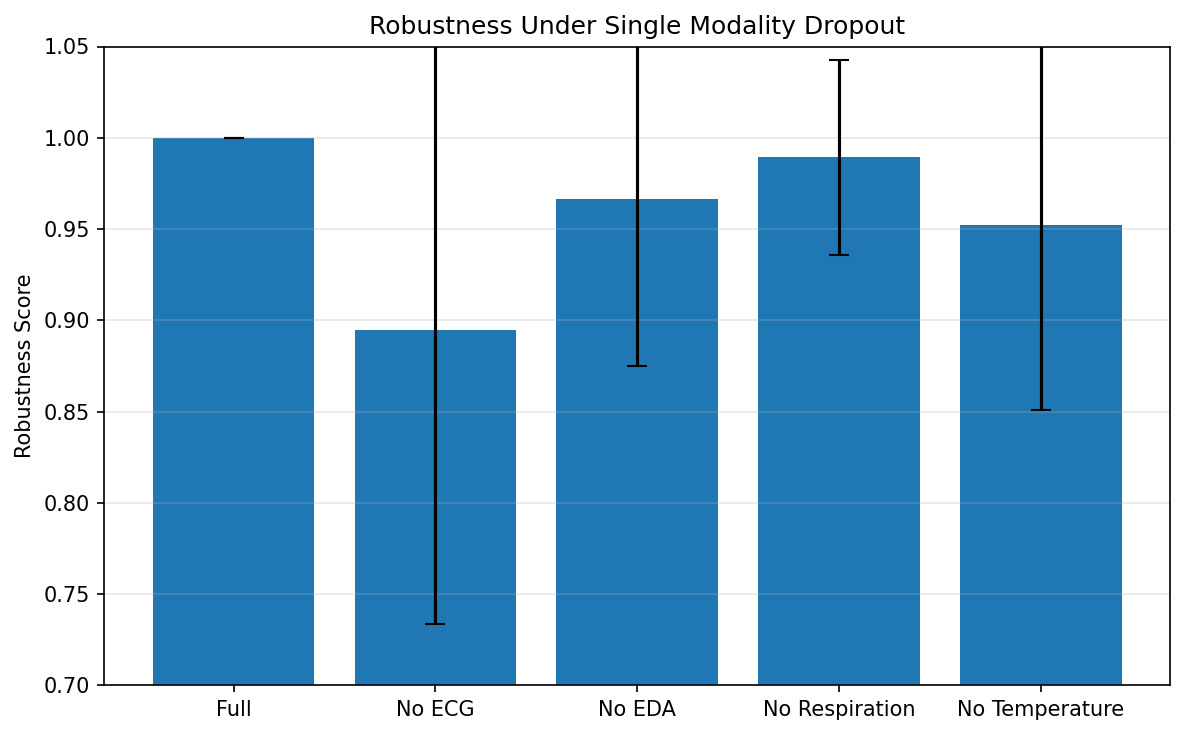

In [34]:
plt.figure()

plt.bar(

    plot_df["Scenario"],

    plot_df["mean"],

    yerr=plot_df["std"],

    capsize=5

)

plt.ylabel("Robustness Score")

plt.title("Robustness Under Single Modality Dropout")

plt.ylim(0.7,1.05)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "single_dropout_RS.png"

)

plt.show()

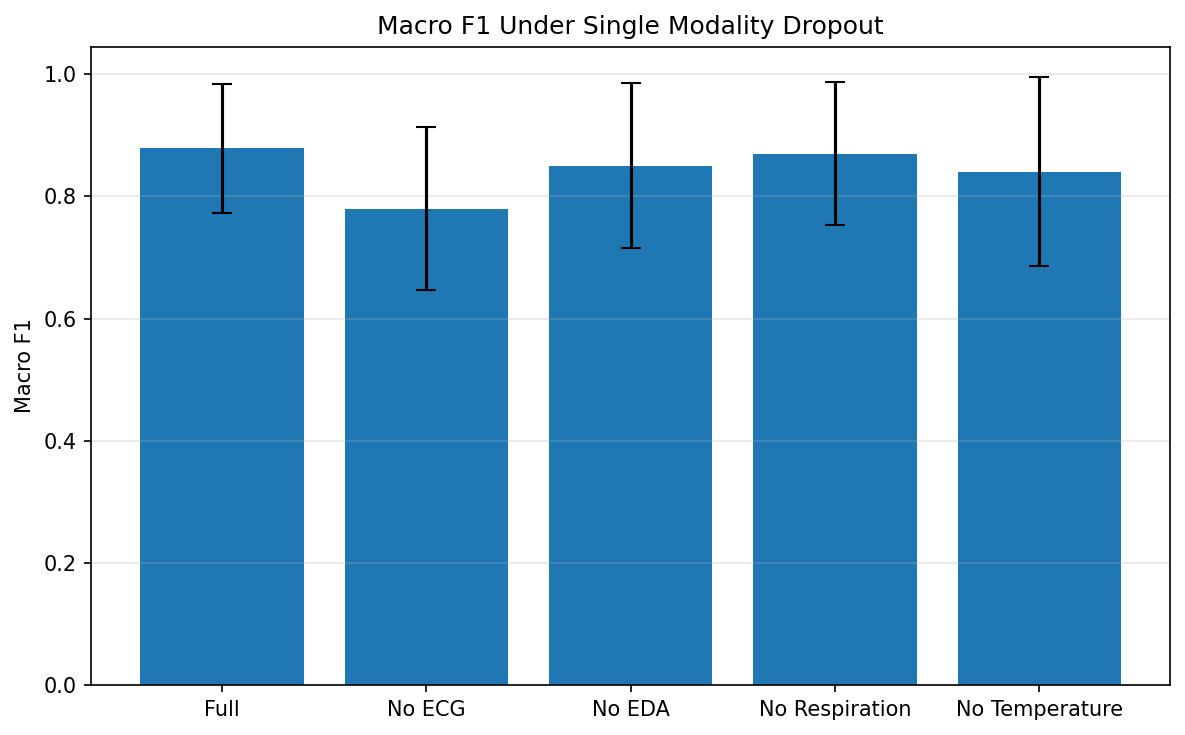

In [35]:
f1_plot = (

    results_df

    .groupby("Scenario")

    ["F1"]

    .agg(["mean","std"])

    .reset_index()

)

plt.figure()

plt.bar(

    f1_plot["Scenario"],

    f1_plot["mean"],

    yerr=f1_plot["std"],

    capsize=5

)

plt.ylabel("Macro F1")

plt.title("Macro F1 Under Single Modality Dropout")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "single_dropout_F1.png"

)

plt.show()

In [36]:
full_f1 = summary_stats.loc["Full",("F1","mean")]

performance_drop = []

for scenario in plot_df["Scenario"]:

    if scenario == "Full":

        performance_drop.append(0)

    else:

        f1 = summary_stats.loc[scenario,("F1","mean")]

        performance_drop.append(

            full_f1 - f1

        )

drop_df = pd.DataFrame({

    "Scenario":plot_df["Scenario"],

    "Drop":performance_drop

})

drop_df

,Scenario,Drop
0,Full,0.0000
1,No ECG,0.0989
2,No EDA,0.0282
3,No Respiration,0.0086
4,No Temperature,0.0381


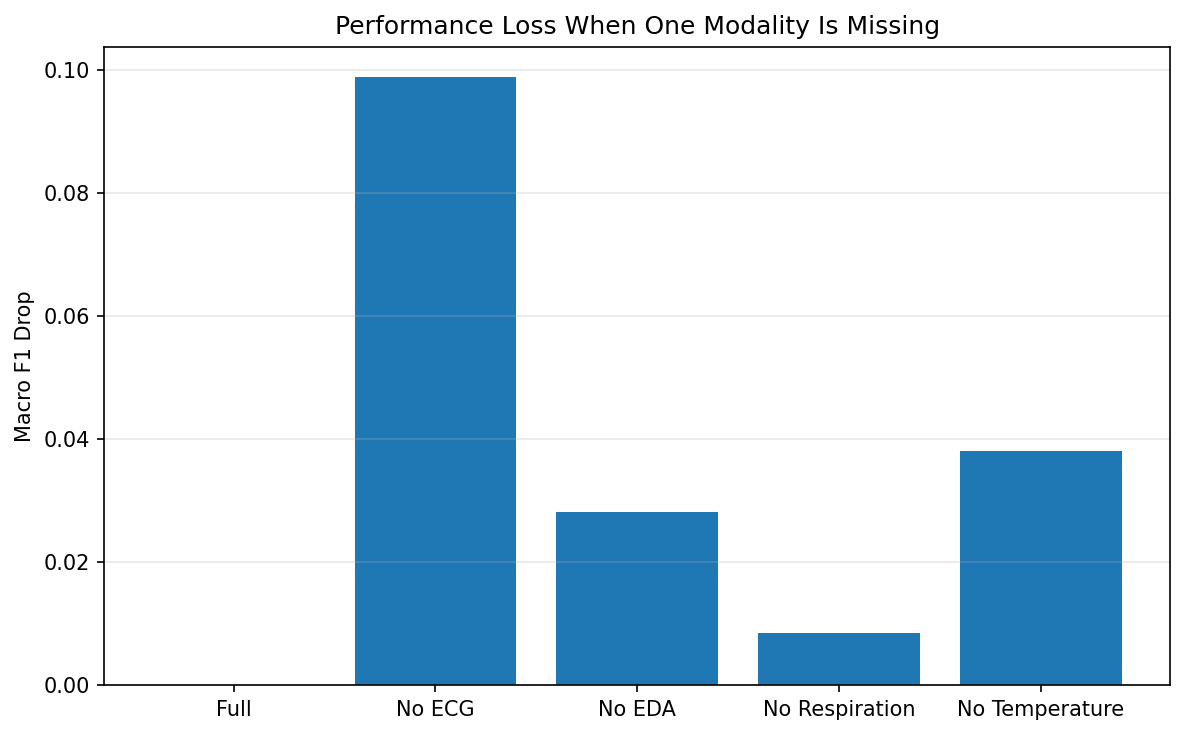

In [37]:
plt.figure()

plt.bar(

    drop_df["Scenario"],

    drop_df["Drop"]

)

plt.ylabel("Macro F1 Drop")

plt.title("Performance Loss When One Modality Is Missing")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "performance_drop.png"

)

plt.show()

In [38]:
ranking = (

    drop_df

    .sort_values(

        "Drop",

        ascending=False

    )

)

ranking

,Scenario,Drop
1,No ECG,0.0989
4,No Temperature,0.0381
2,No EDA,0.0282
3,No Respiration,0.0086
0,Full,0.0000


In [39]:
# ==========================
# Multi-Modality Dropout
# ==========================

MULTI_DROPOUTS = {

    # Two Missing

    "No ECG + No EDA":
        [True, True, False, False],

    "No ECG + No Respiration":
        [True, False, True, False],

    "No ECG + No Temperature":
        [True, False, False, True],

    "No EDA + No Respiration":
        [False, True, True, False],

    "No EDA + No Temperature":
        [False, True, False, True],

    "No Respiration + No Temperature":
        [False, False, True, True],


    # Three Missing

    "Only ECG":
        [False, True, True, True],

    "Only EDA":
        [True, False, True, True],

    "Only Respiration":
        [True, True, False, True],

    "Only Temperature":
        [True, True, True, False]

}

print(len(MULTI_DROPOUTS))

10


In [40]:
def evaluate_subject_multi(subject_id):

    X, y = load_subject(subject_id)

    model = load_checkpoint(subject_id)

    full_result = evaluate_model(
        model,
        X,
        y
    )

    rows = []

    rows.append({

        "Subject": subject_id,

        "Scenario": "Full",

        "Accuracy": full_result["accuracy"],

        "F1": full_result["f1"],

        "AUROC": full_result["auroc"],

        "RS": 1.0

    })

    for scenario, mask in MULTI_DROPOUTS.items():

        result = evaluate_model(
            model,
            X,
            y,
            missing_mask=mask
        )

        rows.append({

            "Subject": subject_id,

            "Scenario": scenario,

            "Accuracy": result["accuracy"],

            "F1": result["f1"],

            "AUROC": result["auroc"],

            "RS": result["f1"] / full_result["f1"]

        })

    return pd.DataFrame(rows)

In [41]:
test_multi = evaluate_subject_multi(2)

test_multi

,Subject,Scenario,Accuracy,F1,AUROC,RS
0,2,Full,0.757143,0.727751,0.802661,1.000000
1,2,No ECG + No EDA,0.742857,0.726740,0.737374,0.998611
2,2,No ECG + No Respiration,0.771429,0.763264,0.749938,1.048798
3,2,No ECG + No Temperature,0.835714,0.818602,0.910076,1.124838
4,2,No EDA + No Respiration,0.564286,0.462183,0.704853,0.635084
5,2,No EDA + No Temperature,0.642857,0.391304,0.765459,0.537690
6,2,No Respiration + No Temperature,0.714286,0.585676,0.499877,0.804775
7,2,Only ECG,0.642857,0.391304,0.235280,0.537690
8,2,Only EDA,0.557143,0.555692,0.835427,0.763574
9,2,Only Respiration,0.800000,0.770760,0.869426,1.059099


In [42]:
multi_results = []

for subject in SUBJECTS:

    print(f"Running Subject {subject}")

    df = evaluate_subject_multi(subject)

    multi_results.append(df)

print("Done!")

Running Subject 2
Running Subject 3
Running Subject 4
Running Subject 5
Running Subject 6
Running Subject 7
Running Subject 8
Running Subject 9
Running Subject 10
Running Subject 11
Running Subject 13
Running Subject 14
Running Subject 15
Running Subject 16
Running Subject 17
Done!


In [43]:
multi_df = pd.concat(
    multi_results,
    ignore_index=True
)

print(multi_df.shape)

(165, 6)


In [44]:
multi_df.to_csv(

    OUTPUT_DIR / "multi_dropout_all_subjects.csv",

    index=False

)

print("Saved!")

Saved!


In [45]:
single_df = pd.read_csv(
    OUTPUT_DIR / "single_dropout_all_subjects.csv"
)

single_df.head()

,Subject,Scenario,Accuracy,F1,AUROC,RS
0,2,Full,0.757143,0.727751,0.802661,1.000000
1,2,No ECG,0.764286,0.752133,0.798473,1.033503
2,2,No EDA,0.685714,0.625850,0.752156,0.859979
3,2,No Respiration,0.642857,0.595282,0.757822,0.817975
4,2,No Temperature,0.721429,0.591287,0.829022,0.812485


In [46]:
full_f1 = (

    single_df[
        single_df["Scenario"]=="Full"
    ]

    .set_index("Subject")["F1"]

)

drops = []

for _, row in single_df.iterrows():

    if row["Scenario"]=="Full":
        continue

    full = full_f1[row["Subject"]]

    drop = (

        (full-row["F1"])

        /full

    )*100

    drops.append({

        "Subject":row["Subject"],

        "Scenario":row["Scenario"],

        "DropPercent":drop

    })

drop_df = pd.DataFrame(drops)

drop_df.head()

,Subject,Scenario,DropPercent
0,2,No ECG,-3.350258
1,2,No EDA,14.002143
2,2,No Respiration,18.202507
3,2,No Temperature,18.751509
4,3,No ECG,1.444680


In [47]:
drop_summary = (

    drop_df

    .groupby("Scenario")

    ["DropPercent"]

    .agg(["mean","std"])

    .round(2)

)

drop_summary

,mean,std
Scenario,,
No ECG,10.51,16.12
No EDA,3.34,9.17
No Respiration,1.07,5.33
No Temperature,4.76,10.17


In [48]:
from scipy.stats import sem

ci_rows=[]

for scenario in drop_df["Scenario"].unique():

    vals = drop_df[

        drop_df["Scenario"]==scenario

    ]["DropPercent"]

    ci = 1.96*sem(vals)

    ci_rows.append({

        "Scenario":scenario,

        "Mean":vals.mean(),

        "95CI":ci

    })

ci_df = pd.DataFrame(ci_rows)

ci_df

,Scenario,Mean,95CI
0,No ECG,10.507252,8.159615
1,No EDA,3.335447,4.641461
2,No Respiration,1.069999,2.695548
3,No Temperature,4.761906,5.145162


In [49]:
from scipy.stats import ttest_rel

full = (

    single_df

    [single_df["Scenario"]=="Full"]

    .sort_values("Subject")

)

tests=[]

for scenario in [

    "No ECG",

    "No EDA",

    "No Respiration",

    "No Temperature"

]:

    other = (

        single_df

        [single_df["Scenario"]==scenario]

        .sort_values("Subject")

    )

    t,p = ttest_rel(

        full["F1"],

        other["F1"]

    )

    tests.append({

        "Scenario":scenario,

        "t-statistic":t,

        "p-value":p

    })

ttest_df = pd.DataFrame(tests)

ttest_df

,Scenario,t-statistic,p-value
0,No ECG,2.819626,0.013643
1,No EDA,1.403697,0.182201
2,No Respiration,0.828398,0.421344
3,No Temperature,1.731100,0.105402


In [50]:
drop_summary.to_csv(

    OUTPUT_DIR / "drop_percentage_summary.csv"

)

ci_df.to_csv(

    OUTPUT_DIR / "confidence_intervals.csv"

)

ttest_df.to_csv(

    OUTPUT_DIR / "paired_t_tests.csv"

)

print("Statistical analysis saved.")

Statistical analysis saved.


In [51]:
drop_summary.to_csv(

    OUTPUT_DIR / "drop_percentage_summary.csv"

)

ci_df.to_csv(

    OUTPUT_DIR / "confidence_intervals.csv"

)

ttest_df.to_csv(

    OUTPUT_DIR / "paired_t_tests.csv"

)

print("Statistical analysis saved.")

Statistical analysis saved.


In [52]:
paper_table = pd.DataFrame({
    "Scenario": summary_stats.index,
    "Accuracy (Mean±Std)": [
        f"{summary_stats.loc[s,('Accuracy','mean')]:.3f} ± {summary_stats.loc[s,('Accuracy','std')]:.3f}"
        for s in summary_stats.index
    ],
    "F1 (Mean±Std)": [
        f"{summary_stats.loc[s,('F1','mean')]:.3f} ± {summary_stats.loc[s,('F1','std')]:.3f}"
        for s in summary_stats.index
    ],
    "AUROC (Mean±Std)": [
        f"{summary_stats.loc[s,('AUROC','mean')]:.3f} ± {summary_stats.loc[s,('AUROC','std')]:.3f}"
        for s in summary_stats.index
    ],
    "RS (Mean±Std)": [
        f"{summary_stats.loc[s,('RS','mean')]:.3f} ± {summary_stats.loc[s,('RS','std')]:.3f}"
        for s in summary_stats.index
    ]
})

paper_table

,Scenario,Accuracy (Mean±Std),F1 (Mean±Std),AUROC (Mean±Std),RS (Mean±Std)
0,Full,0.897 ± 0.094,0.879 ± 0.105,0.948 ± 0.076,1.000 ± 0.000
1,No ECG,0.816 ± 0.106,0.780 ± 0.133,0.905 ± 0.078,0.895 ± 0.161
2,No EDA,0.880 ± 0.112,0.850 ± 0.135,0.926 ± 0.108,0.967 ± 0.092
3,No Respiration,0.890 ± 0.105,0.870 ± 0.118,0.947 ± 0.081,0.989 ± 0.053
4,No Temperature,0.873 ± 0.125,0.841 ± 0.155,0.921 ± 0.113,0.952 ± 0.102


In [53]:
paper_table.to_csv(
    OUTPUT_DIR / "paper_table_single_dropout.csv",
    index=False
)

print("Paper table saved.")

Paper table saved.


In [54]:
ranking = (

    summary_stats
    .loc[summary_stats.index != "Full"]

    .sort_values(
        ("RS","mean")
    )

)

ranking

Accuracy              F1           AUROC              RS  \
                   mean     std    mean     std    mean     std    mean   
Scenario                                                                  
No ECG           0.8159  0.1060  0.7797  0.1332  0.9046  0.0783  0.8949   
No Temperature   0.8733  0.1252  0.8405  0.1548  0.9208  0.1126  0.9524   
No EDA           0.8799  0.1115  0.8504  0.1348  0.9264  0.1076  0.9666   
No Respiration   0.8898  0.1046  0.8700  0.1176  0.9471  0.0808  0.9893   

                        
                   std  
Scenario                
No ECG          0.1612  
No Temperature  0.1017  
No EDA          0.0917  
No Respiration  0.0533

In [55]:
ranking.to_csv(
    OUTPUT_DIR / "modality_importance.csv"
)

print("Ranking saved.")

Ranking saved.


In [56]:
corr = single_df["RS"].corr(single_df["F1"])

print(f"Correlation = {corr:.4f}")

Correlation = 0.6421


In [57]:
best = ranking.index[0]
worst = ranking.index[-1]

print("Most important modality :", best)
print("Least important modality:", worst)

print()

print("Mean RS values")

print(summary_stats[("RS","mean")])

Most important modality : No ECG
Least important modality: No Respiration

Mean RS values
Scenario
Full              1.0000
No ECG            0.8949
No EDA            0.9666
No Respiration    0.9893
No Temperature    0.9524
Name: (RS, mean), dtype: float64


In [59]:
paper_table.to_excel(
    OUTPUT_DIR / "paper_table_single_dropout.xlsx",
    index=False
)

print("Excel version saved.")

Excel version saved.


In [60]:
# ==========================
# Load Multi-Dropout Results
# ==========================

multi_df = pd.read_csv(
    OUTPUT_DIR / "multi_dropout_all_subjects.csv"
)

print("Shape:", multi_df.shape)

multi_df.head()

Shape: (165, 6)


,Subject,Scenario,Accuracy,F1,AUROC,RS
0,2,Full,0.757143,0.727751,0.802661,1.000000
1,2,No ECG + No EDA,0.742857,0.726740,0.737374,0.998611
2,2,No ECG + No Respiration,0.771429,0.763264,0.749938,1.048798
3,2,No ECG + No Temperature,0.835714,0.818602,0.910076,1.124838
4,2,No EDA + No Respiration,0.564286,0.462183,0.704853,0.635084


In [61]:
print("Subjects :", multi_df["Subject"].nunique())
print("Scenarios:", multi_df["Scenario"].nunique())

print(multi_df["Scenario"].value_counts())

Subjects : 15
Scenarios: 11
Scenario
Full                               15
No ECG + No EDA                    15
No ECG + No Respiration            15
No ECG + No Temperature            15
No EDA + No Respiration            15
No EDA + No Temperature            15
No Respiration + No Temperature    15
Only ECG                           15
Only EDA                           15
Only Respiration                   15
Only Temperature                   15
Name: count, dtype: int64


In [62]:
multi_summary = (

    multi_df

    .groupby("Scenario")

    .agg({

        "Accuracy":["mean","std"],
        "F1":["mean","std"],
        "AUROC":["mean","std"],
        "RS":["mean","std"]

    })

    .round(4)

)

multi_summary

Accuracy              F1           AUROC  \
                                    mean     std    mean     std    mean   
Scenario                                                                   
Full                              0.8970  0.0941  0.8786  0.1052  0.9481   
No ECG + No EDA                   0.7701  0.1263  0.7294  0.1662  0.8387   
No ECG + No Respiration           0.7974  0.1231  0.7602  0.1471  0.8868   
No ECG + No Temperature           0.7726  0.1585  0.7297  0.1741  0.9034   
No EDA + No Respiration           0.8576  0.1320  0.8183  0.1690  0.9179   
No EDA + No Temperature           0.8164  0.1844  0.7716  0.2214  0.8666   
No Respiration + No Temperature   0.8647  0.1244  0.8280  0.1620  0.8919   
Only ECG                          0.7762  0.2054  0.7315  0.2374  0.8205   
Only EDA                          0.7639  0.1875  0.7251  0.2076  0.8933   
Only Respiration                  0.7213  0.1143  0.6281  0.1537  0.7341   
Only Temperature                  0.7575  0.1639  0.7252  0.1951  0.8114   

                                             RS          
                                    std    mean     std  
Scenario                                                 
Full                             0.0759  1.0000  0.0000  
No ECG + No EDA                  0.1531  0.8403  0.2124  
No ECG + No Respiration          0.1052  0.8756  0.1933  
No ECG + No Temperature          0.0744  0.8427  0.2308  
No EDA + No Respiration          0.1176  0.9283  0.1442  
No EDA + No Temperature          0.1617  0.8692  0.1985  
No Respiration + No Temperature  0.1679  0.9404  0.1304  
Only ECG                         0.2476  0.8239  0.2218  
Only EDA                         0.0826  0.8326  0.2448  
Only Respiration                 0.1587  0.7209  0.1799  
Only Temperature                 0.2012  0.8372  0.2490

In [63]:
multi_summary.to_csv(
    OUTPUT_DIR / "multi_dropout_statistics.csv"
)

print("Saved!")

Saved!


In [64]:
ranking = (

    multi_summary

    .loc[multi_summary.index!="Full"]

    .sort_values(

        ("RS","mean")

    )

)

ranking

Accuracy              F1           AUROC  \
                                    mean     std    mean     std    mean   
Scenario                                                                   
Only Respiration                  0.7213  0.1143  0.6281  0.1537  0.7341   
Only ECG                          0.7762  0.2054  0.7315  0.2374  0.8205   
Only EDA                          0.7639  0.1875  0.7251  0.2076  0.8933   
Only Temperature                  0.7575  0.1639  0.7252  0.1951  0.8114   
No ECG + No EDA                   0.7701  0.1263  0.7294  0.1662  0.8387   
No ECG + No Temperature           0.7726  0.1585  0.7297  0.1741  0.9034   
No EDA + No Temperature           0.8164  0.1844  0.7716  0.2214  0.8666   
No ECG + No Respiration           0.7974  0.1231  0.7602  0.1471  0.8868   
No EDA + No Respiration           0.8576  0.1320  0.8183  0.1690  0.9179   
No Respiration + No Temperature   0.8647  0.1244  0.8280  0.1620  0.8919   

                                             RS          
                                    std    mean     std  
Scenario                                                 
Only Respiration                 0.1587  0.7209  0.1799  
Only ECG                         0.2476  0.8239  0.2218  
Only EDA                         0.0826  0.8326  0.2448  
Only Temperature                 0.2012  0.8372  0.2490  
No ECG + No EDA                  0.1531  0.8403  0.2124  
No ECG + No Temperature          0.0744  0.8427  0.2308  
No EDA + No Temperature          0.1617  0.8692  0.1985  
No ECG + No Respiration          0.1052  0.8756  0.1933  
No EDA + No Respiration          0.1176  0.9283  0.1442  
No Respiration + No Temperature  0.1679  0.9404  0.1304

In [65]:
ranking.to_csv(
    OUTPUT_DIR / "multi_modality_ranking.csv"
)

print("Ranking saved.")

Ranking saved.


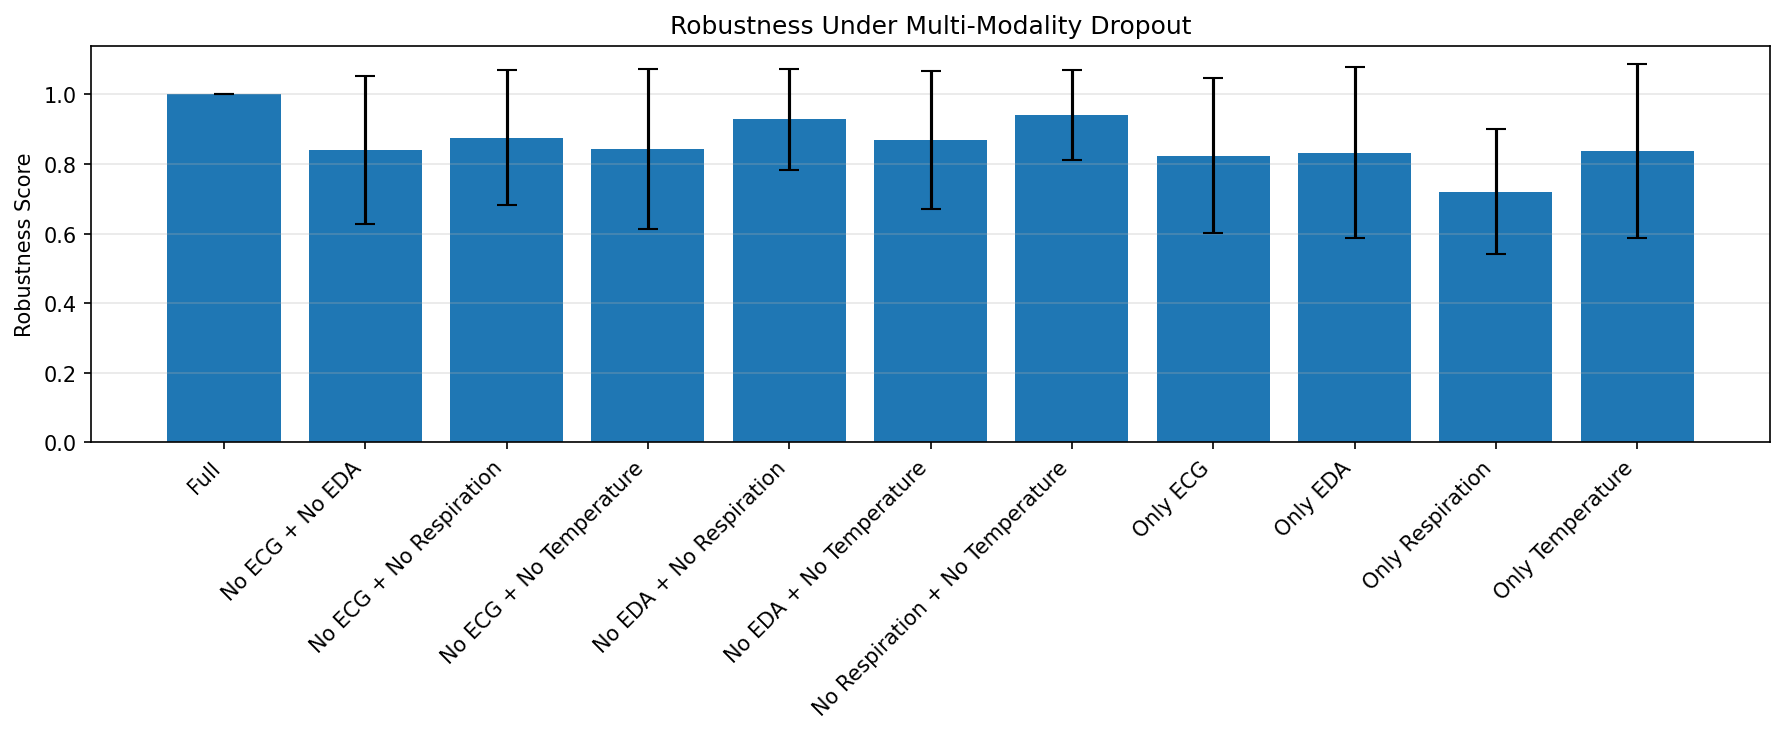

In [66]:
plot_df = (

    multi_df

    .groupby("Scenario")

    ["RS"]

    .agg(["mean","std"])

    .reset_index()

)

plt.figure(figsize=(12,5))

plt.bar(
    plot_df["Scenario"],
    plot_df["mean"],
    yerr=plot_df["std"],
    capsize=5
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Robustness Score")

plt.title("Robustness Under Multi-Modality Dropout")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "multi_dropout_RS.png"
)

plt.show()

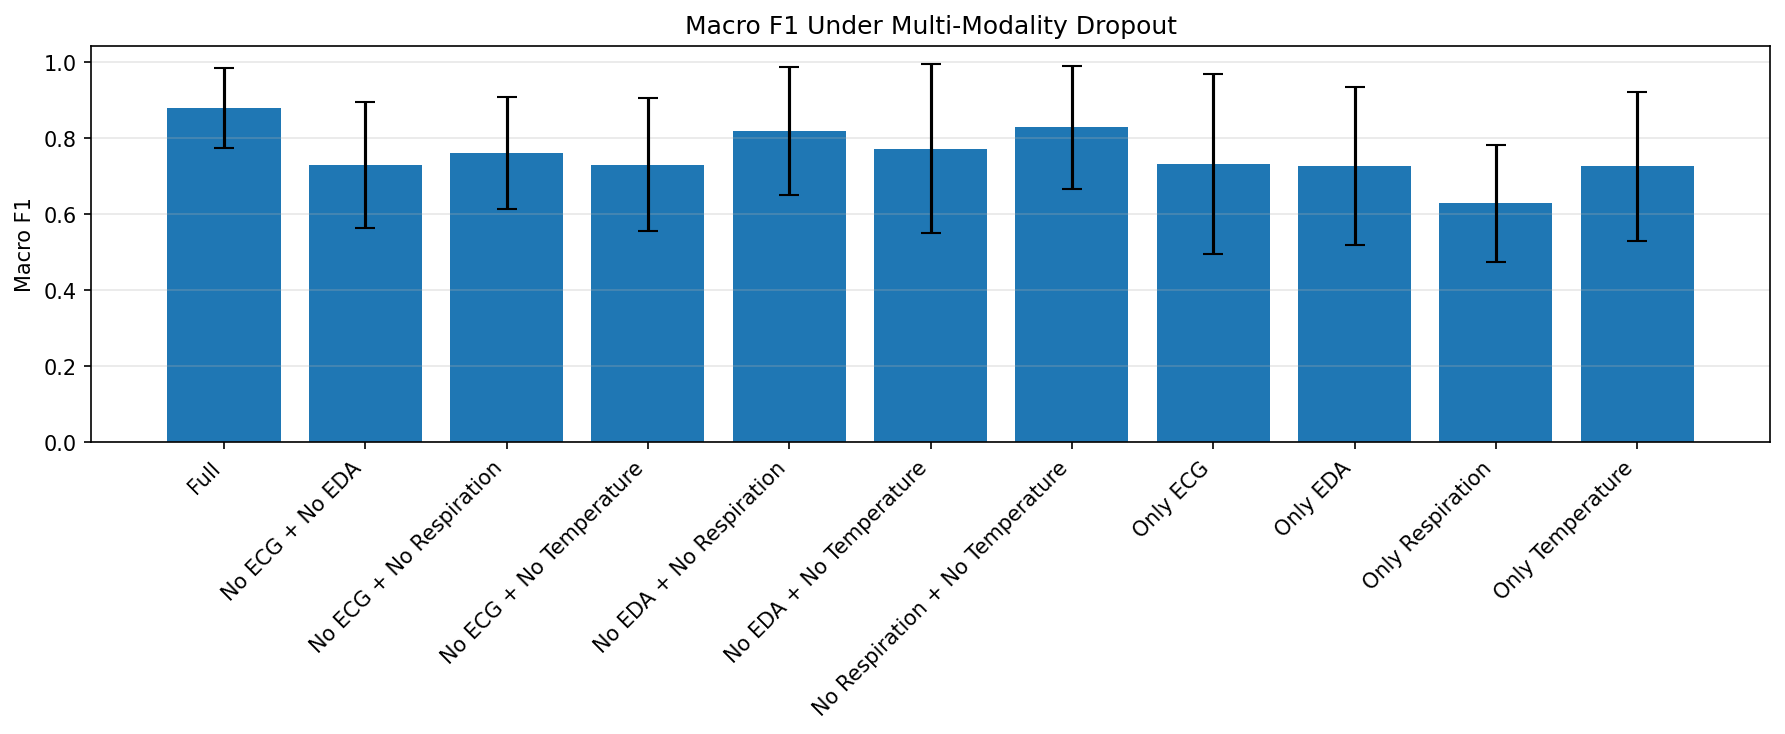

In [67]:
plot_df = (

    multi_df

    .groupby("Scenario")

    ["F1"]

    .agg(["mean","std"])

    .reset_index()

)

plt.figure(figsize=(12,5))

plt.bar(
    plot_df["Scenario"],
    plot_df["mean"],
    yerr=plot_df["std"],
    capsize=5
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Macro F1")

plt.title("Macro F1 Under Multi-Modality Dropout")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "multi_dropout_F1.png"
)

plt.show()

In [68]:
single_summary = pd.read_csv(
    OUTPUT_DIR / "single_dropout_summary.csv"
)

multi_simple = (

    multi_df

    .groupby("Scenario")

    [["F1","RS"]]

    .mean()

    .round(4)

)

print("Single Dropout")

print(single_summary)

print()

print("Multi Dropout")

print(multi_simple)

Single Dropout
         Scenario  Accuracy      F1   AUROC      RS
0            Full    0.8970  0.8786  0.9481  1.0000
1          No ECG    0.8159  0.7797  0.9046  0.8949
2          No EDA    0.8799  0.8504  0.9264  0.9666
3  No Respiration    0.8898  0.8700  0.9471  0.9893
4  No Temperature    0.8733  0.8405  0.9208  0.9524

Multi Dropout
                                     F1      RS
Scenario                                       
Full                             0.8786  1.0000
No ECG + No EDA                  0.7294  0.8403
No ECG + No Respiration          0.7602  0.8756
No ECG + No Temperature          0.7297  0.8427
No EDA + No Respiration          0.8183  0.9283
No EDA + No Temperature          0.7716  0.8692
No Respiration + No Temperature  0.8280  0.9404
Only ECG                         0.7315  0.8239
Only EDA                         0.7251  0.8326
Only Respiration                 0.6281  0.7209
Only Temperature                 0.7252  0.8372


In [69]:
multi_summary.to_csv(
    OUTPUT_DIR / "paper_multi_dropout_table.csv"
)